[  100.   102.   104. ... 18000. 19000. 20000.]
Filename: /home/yu/XRT/caldb/data/swift/xrt/cpf/rmf/swxpc0to12s6_20130101v014.rmf
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      10   ()      
  1  MATRIX        1 BinTableHDU    101   2400R x 6C   [E, E, I, I, I, 1024E]   
  2  EBOUNDS       1 BinTableHDU     46   1024R x 3C   [I, E, E]   
20.670405433953587
[ 0.22   0.225  0.23  ... 10.995 11.    11.005]


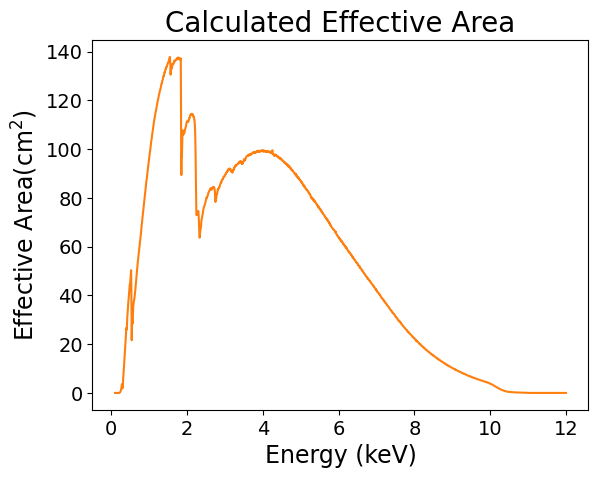

In [3]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

## mirror ##
mirr = fits.open('/home/yu/XRT/caldb/data/swift/xrt/bcf/effarea/swxeffarea20010101v004.fits')
mirrarea = mirr['EFFAREA'].data
E=mirrarea['ENERGY']
A=mirrarea['AREA']
f_m = interp1d(E, A, kind='linear')

## filter ##
trans = fits.open('/home/yu/XRT/caldb/data/swift/xrt/bcf/ftrans/swxftrans20010101v005.fits')
transmission = trans['TRANSMISSION'].data
E=transmission['ENERGY']
print(E)
T=transmission['TRANSMIS']
f_t = interp1d(E, T, kind='linear')


## QE ##
rmfhdul = fits.open('/home/yu/XRT/caldb/data/swift/xrt/cpf/rmf/swxpc0to12s6_20130101v014.rmf') 
 # there is another rmf file /home/yu/XRT/caldb/data/swift/xrt/cpf/rmf/swxpc0to12s6_20210101v016.rmf 
 # In principle, data taken after 2021 are supposed to be analyzed by this new version file
 # but I confirmed the difference of both files is negligible so I use 2013 version file even for recent observations
 
rmfhdul.info()
matrix=rmfhdul['MATRIX'].data
energy = (matrix['ENERG_HI']+matrix['ENERG_LO'])/2
prob = matrix['MATRIX']
prob_sum = np.array([x.sum() for x in prob])
f_q = interp1d(energy, prob_sum, kind='linear') 
# plt.plot(energy, prob_sum)
# plt.show()

# hdul_caldb = fits.open('/home/yu/XRT/caldb/data/swift/xrt/cpf/arf/swxs6_20010101v001.arf')
# data_caldb = hdul_caldb['SPECRESP'].data

# energ_lo_caldb = data_caldb['ENERG_LO']
# energ_hi_caldb = data_caldb['ENERG_HI']
# specresp_caldb = data_caldb['SPECRESP']
# energy_caldb = (energ_lo_caldb+energ_hi_caldb)/2
# f_arf=interp1d(energy_caldb, specresp_caldb, kind='linear')


e = np.arange(100, 11996, 5)
e_kev = e/1e3
eff = f_m(e)*f_t(e)*f_q(e_kev)
# np.save('/home/yu/XRT/e_kev_2021.npy', e_kev)
# np.save('/home/yu/XRT/fm_ft_fq_2021.npy', eff)


e_keV = np.load('/home/yu/XRT/e_kev.npy')
eff = np.load('//home/yu/XRT/fm_ft_fq.npy')
# eff=f_arf(e_kev)*f_q(e_kev)
print(f_m(8100)*f_t(8100)*f_q(8.1))
plt.title('Calculated Effective Area', fontsize=20)
plt.plot(e_kev, eff, color='tab:orange')
plt.xlabel('Energy (keV)', fontsize=17)
plt.ylabel(r'Effective Area(cm$^2$)', fontsize=17)
plt.tick_params(labelsize=14)
plt.savefig('/home/yu/XRT/Git/Swift_calibrations/effectivearea.png')
# plt.xscale('log')
# plt.vlines(3e-1, 0, 140, color='blue')
# plt.xlim(0.2, 10)
# plt.ylim(0, 150)

print(e_kev[eff>0])

